# Assignment 4 - Part 3: Variational Autoencoder on Fashion-MNIST

This notebook solves **Part 3 only** of Assignment 4. The goal is to build a Variational Autoencoder (VAE), train beta-VAE variants with different KL-divergence weights, and study how beta changes reconstruction quality, generated samples, and the 2D latent space.

Fashion-MNIST is the main dataset because it is built into Keras, uses small 28 by 28 grayscale images, and gives more visually meaningful reconstruction examples than digit-only MNIST. 


## 1. Imports and Configuration



In [1]:
import os
from pathlib import Path

os.environ.setdefault("KERAS_HOME", str((Path.cwd() / ".keras").resolve()))
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

RANDOM_SEED = 42
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1
LATENT_DIM = 2
BATCH_SIZE = 128
EPOCHS = 5
TRAIN_SUBSET_SIZE = 20000
VAL_SUBSET_SIZE = 5000
TEST_VIS_SIZE = 2000
BETAS = [0.1, 1.0, 4.0]
OUTPUT_DIR = Path("outputs")
MODEL_DIR = Path("models")
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)


Now we import the scientific Python and TensorFlow/Keras libraries. Setting the random seed makes the data subsets, initial weights, and random latent samples as reproducible as TensorFlow allows on the current hardware.


In [2]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from IPython.display import Markdown, display

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)

print("TensorFlow version:", tf.__version__)
print("Keras home:", os.environ["KERAS_HOME"])


TensorFlow version: 2.21.0
Keras home: D:\SHARIF\TERM7\DATA\HW4\PART3\.keras


## 2. Load Fashion-MNIST Dataset

The VAE is trained as an unsupervised model, so labels are not used during optimization. We keep labels only for EDA and for coloring the 2D latent-space scatter plots.



In [3]:
FASHION_CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

MNIST_CLASS_NAMES = [str(i) for i in range(10)]


def load_keras_image_dataset():
    try:
        (x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.fashion_mnist.load_data()
        return "Fashion-MNIST", FASHION_CLASS_NAMES, x_train_raw, y_train_raw, x_test_raw, y_test_raw, None
    except Exception as fashion_error:
        print("Fashion-MNIST could not be loaded. Trying MNIST fallback.")
        print("Fashion-MNIST error:", repr(fashion_error))
        try:
            (x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()
            return "MNIST", MNIST_CLASS_NAMES, x_train_raw, y_train_raw, x_test_raw, y_test_raw, fashion_error
        except Exception as mnist_error:
            raise RuntimeError(
                "Neither Fashion-MNIST nor MNIST could be loaded through Keras. "
                "Check network access or the local Keras cache."
            ) from mnist_error


dataset_name, class_names, x_train_raw, y_train_raw, x_test_raw, y_test_raw, dataset_fallback_error = load_keras_image_dataset()

print("Dataset:", dataset_name)
print("Raw train images:", x_train_raw.shape, x_train_raw.dtype)
print("Raw test images:", x_test_raw.shape, x_test_raw.dtype)
print("Raw pixel range:", int(x_train_raw.min()), "to", int(x_train_raw.max()))


Dataset: Fashion-MNIST
Raw train images: (60000, 28, 28) uint8
Raw test images: (10000, 28, 28) uint8
Raw pixel range: 0 to 255


Next we normalize the images to `[0, 1]`, convert them to `float32`, and add the channel dimension expected by convolutional layers. This makes every image tensor shape `(28, 28, 1)`.

Normalization helps neural networks train more stably because the optimizer sees small, consistent numeric inputs instead of raw pixel values from 0 to 255.


In [4]:
def preprocess_images(images):
    images = images.astype("float32") / 255.0
    return np.expand_dims(images, axis=-1)


x_train_all = preprocess_images(x_train_raw)
x_test_all = preprocess_images(x_test_raw)

rng = np.random.default_rng(RANDOM_SEED)
train_order = rng.permutation(len(x_train_all))
train_idx = train_order[:TRAIN_SUBSET_SIZE]
val_idx = train_order[TRAIN_SUBSET_SIZE:TRAIN_SUBSET_SIZE + VAL_SUBSET_SIZE]
test_idx = rng.permutation(len(x_test_all))[:TEST_VIS_SIZE]

x_train = x_train_all[train_idx]
y_train = y_train_raw[train_idx]
x_val = x_train_all[val_idx]
y_val = y_train_raw[val_idx]
x_test_vis = x_test_all[test_idx]
y_test_vis = y_test_raw[test_idx]

print("x_train:", x_train.shape, x_train.dtype)
print("x_val:", x_val.shape, x_val.dtype)
print("x_test_vis:", x_test_vis.shape, x_test_vis.dtype)
print("Normalized train pixel range:", float(x_train.min()), "to", float(x_train.max()))


x_train: (20000, 28, 28, 1) float32
x_val: (5000, 28, 28, 1) float32
x_test_vis: (2000, 28, 28, 1) float32


Normalized train pixel range: 0.0 to 1.0


## 3. Quick Image EDA

Before training the VAE, we inspect a few images and the class distribution of the training subset. This confirms that the subset is shaped correctly and still contains all classes.


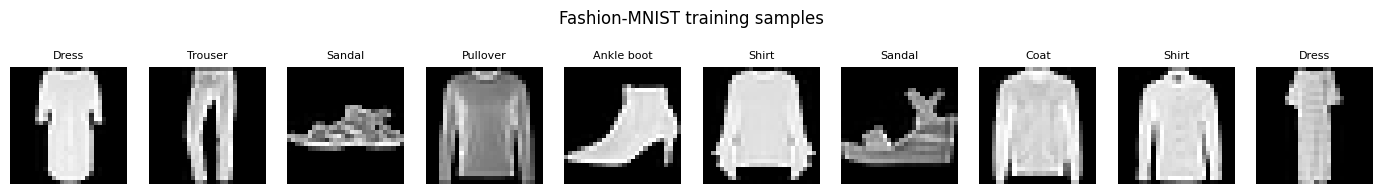

In [5]:
def plot_image_grid(images, title, n=10, labels=None, class_names=None, save_path=None):
    count = min(n, len(images))
    fig, axes = plt.subplots(1, count, figsize=(1.4 * count, 1.8))
    if count == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ax.imshow(images[i].squeeze(), cmap="gray")
        ax.axis("off")
        if labels is not None and class_names is not None:
            ax.set_title(class_names[int(labels[i])], fontsize=8)
    fig.suptitle(title, y=1.05)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig


sample_indices = np.arange(10)
plot_image_grid(
    x_train[sample_indices],
    f"{dataset_name} training samples",
    n=10,
    labels=y_train[sample_indices],
    class_names=class_names,
    save_path=FIGURE_DIR / "sample_images.png",
)
plt.show()


The class-count table and bar chart below use labels only for inspection. The VAE itself receives only images during training.


,class_id,class_name,count
0,0,T-shirt/top,1973
1,1,Trouser,2000
2,2,Pullover,2040
3,3,Dress,1983
4,4,Coat,1974
5,5,Sandal,2037
6,6,Shirt,1951
7,7,Sneaker,2041
8,8,Bag,1947
9,9,Ankle boot,2054


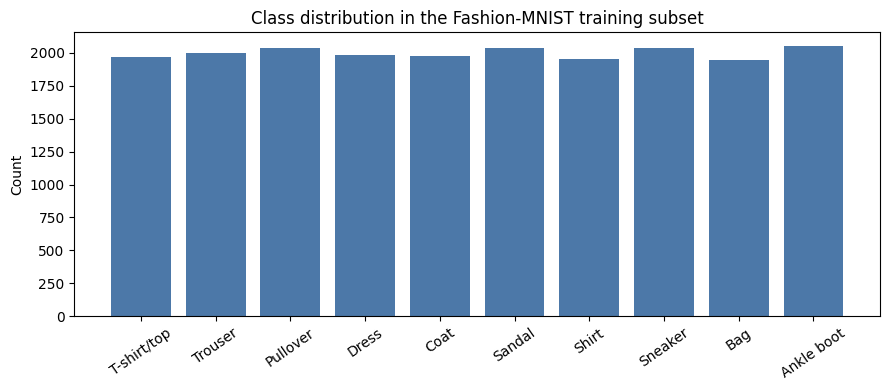

,stage,min,max,dtype
0,raw train,0.0,255.0,uint8
1,normalized train,0.0,1.0,float32


In [6]:
class_counts = pd.Series(y_train).value_counts().sort_index()
class_distribution = pd.DataFrame({
    "class_id": class_counts.index,
    "class_name": [class_names[int(i)] for i in class_counts.index],
    "count": class_counts.values,
})
display(class_distribution)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(class_distribution["class_name"], class_distribution["count"], color="#4C78A8")
ax.set_title(f"Class distribution in the {dataset_name} training subset")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

pixel_ranges = pd.DataFrame({
    "stage": ["raw train", "normalized train"],
    "min": [float(x_train_raw.min()), float(x_train.min())],
    "max": [float(x_train_raw.max()), float(x_train.max())],
    "dtype": [str(x_train_raw.dtype), str(x_train.dtype)],
})
display(pixel_ranges)


## 4. VAE Concept

A VAE has three main parts:

- The encoder maps an image to two latent distribution parameters: `z_mean` and `z_log_var`.
- The sampling layer uses the reparameterization trick: `z = mean + exp(0.5 * log_var) * epsilon`.
- The decoder maps a sampled latent vector back to an image.




## 5. Helper Visualization Functions

These helpers keep the experiment cells short and consistent. They also save lightweight figures to `outputs/figures` so important visuals are easy to find after the notebook runs.


In [7]:
def plot_reconstruction_grid(originals, reconstructions, title, n=10, save_path=None):
    count = min(n, len(originals), len(reconstructions))
    fig, axes = plt.subplots(2, count, figsize=(1.4 * count, 3.0))
    for i in range(count):
        axes[0, i].imshow(originals[i].squeeze(), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(reconstructions[i].squeeze(), cmap="gray")
        axes[1, i].axis("off")
    axes[0, 0].set_ylabel("Original", fontsize=10)
    axes[1, 0].set_ylabel("Rebuilt", fontsize=10)
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig


def plot_generated_grid(generated_images, title, n=25, save_path=None):
    count = min(n, len(generated_images))
    cols = int(np.ceil(np.sqrt(count)))
    rows = int(np.ceil(count / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(1.3 * cols, 1.3 * rows))
    axes = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < count:
            ax.imshow(np.clip(generated_images[i].squeeze(), 0, 1), cmap="gray")
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig


def plot_training_curves(history_dict, beta, save_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
    metric_pairs = [
        ("total_loss", "val_total_loss", "Total loss"),
        ("reconstruction_loss", "val_reconstruction_loss", "Reconstruction loss"),
        ("kl_loss", "val_kl_loss", "KL loss"),
    ]
    for ax, (train_key, val_key, title) in zip(axes, metric_pairs):
        ax.plot(history_dict[train_key], marker="o", label="train")
        if val_key in history_dict:
            ax.plot(history_dict[val_key], marker="s", label="validation")
        ax.set_title(f"{title}, beta={beta}")
        ax.set_xlabel("Epoch")
        ax.legend()
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig


def plot_latent_space(encoder, x_data, y_data, class_names, title, n_samples=2000, save_path=None):
    n = min(n_samples, len(x_data))
    z_mean, _, _ = encoder.predict(x_data[:n], batch_size=BATCH_SIZE, verbose=0)
    fig, ax = plt.subplots(figsize=(7, 6))
    scatter = ax.scatter(z_mean[:, 0], z_mean[:, 1], c=y_data[:n], cmap="tab10", s=8, alpha=0.65)
    ax.set_title(title)
    ax.set_xlabel("z_mean[0]")
    ax.set_ylabel("z_mean[1]")
    cbar = fig.colorbar(scatter, ax=ax, ticks=range(len(class_names)))
    cbar.ax.set_yticklabels(class_names)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig


def interpolate_and_plot(decoder, z_start, z_end, steps=10, title="", save_path=None):
    weights = np.linspace(0.0, 1.0, steps).astype("float32")
    z_values = np.array([(1 - w) * z_start + w * z_end for w in weights], dtype="float32")
    generated = decoder.predict(z_values, verbose=0)
    fig = plot_image_grid(generated, title, n=steps, save_path=save_path)
    return fig, generated


def sample_random_latent_and_generate(decoder, latent_dim, n=25, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    z = rng.normal(size=(n, latent_dim)).astype("float32")
    return decoder.predict(z, verbose=0)


def reconstruct_with_mean(encoder, decoder, images):
    z_mean, _, _ = encoder.predict(images, batch_size=BATCH_SIZE, verbose=0)
    return decoder.predict(z_mean, batch_size=BATCH_SIZE, verbose=0)


## 6. Sampling Layer

The sampling layer implements the reparameterization trick. This lets gradients flow through the stochastic latent sample by separating the random noise `epsilon` from the learned mean and variance parameters.


In [8]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


dummy_mean = tf.zeros((4, LATENT_DIM))
dummy_log_var = tf.zeros((4, LATENT_DIM))
dummy_sample = Sampling()([dummy_mean, dummy_log_var])
print("Sampling output shape:", dummy_sample.shape)


Sampling output shape: (4, 2)


The dummy check confirms that the sampling layer preserves the batch size and latent dimension. Next we use it inside the encoder.


## 7. Encoder

The encoder uses convolutional layers because nearby pixels in images are spatially related. The final dense layers produce `z_mean` and `z_log_var`, and the sampling layer produces the latent vector `z`.


In [9]:
def build_encoder(latent_dim=LATENT_DIM):
    encoder_inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), name="encoder_input")
    x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(encoder_inputs)
    x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling(name="z")([z_mean, z_log_var])
    return keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")


encoder_preview = build_encoder()
encoder_preview.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │        320 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │    200,768 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        130 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        130 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Sampling)        │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 219,844 (858.77 KB)

 Trainable params: 219,844 (858.77 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Decoder

The decoder maps a latent vector back to an image. The final sigmoid activation matches the normalized pixel range `[0, 1]`, so decoder outputs can be interpreted as reconstructed grayscale pixel intensities.


In [10]:
def build_decoder(latent_dim=LATENT_DIM):
    latent_inputs = keras.Input(shape=(latent_dim,), name="decoder_input")
    x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
    decoder_outputs = layers.Conv2DTranspose(1, 3, padding="same", activation="sigmoid", name="decoder_output")(x)
    return keras.Model(latent_inputs, decoder_outputs, name="decoder")


decoder_preview = build_decoder()
decoder_preview.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output                  │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Custom VAE Model

The custom model gives direct control over the VAE loss. Reconstruction loss is binary cross-entropy summed over pixels. KL loss is averaged over the batch after summing the latent dimensions. Beta scales the KL term.


In [11]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, inputs, training=False):
        _, _, z = self.encoder(inputs, training=training)
        return self.decoder(z, training=training)

    def compute_losses(self, data, training=False):
        data = tf.convert_to_tensor(data, dtype=tf.float32)
        z_mean, z_log_var, z = self.encoder(data, training=training)
        reconstruction = self.decoder(z, training=training)

        eps = tf.constant(keras.backend.epsilon(), dtype=reconstruction.dtype)
        reconstruction_safe = tf.clip_by_value(reconstruction, eps, 1.0 - eps)
        bce = -(
            data * tf.math.log(reconstruction_safe)
            + (1.0 - data) * tf.math.log(1.0 - reconstruction_safe)
        )
        reconstruction_loss = tf.reduce_mean(tf.reduce_sum(bce, axis=(1, 2, 3)))
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1.0 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1,
            )
        )
        total_loss = reconstruction_loss + self.beta * kl_loss
        return total_loss, reconstruction_loss, kl_loss, reconstruction

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            total_loss, reconstruction_loss, kl_loss, _ = self.compute_losses(data, training=True)
        gradients = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {metric.name: metric.result() for metric in self.metrics}

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        total_loss, reconstruction_loss, kl_loss, _ = self.compute_losses(data, training=False)
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {metric.name: metric.result() for metric in self.metrics}


We now run a small shape and loss check before full training. This catches common VAE mistakes such as incorrect decoder output shape, broken sampling shape, or non-finite losses.


In [12]:
shape_encoder = build_encoder()
shape_decoder = build_decoder()
shape_vae = VAE(shape_encoder, shape_decoder, beta=1.0, name="vae_shape_check")
shape_vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

small_batch = x_train[:8]
z_mean_check, z_log_var_check, z_check = shape_encoder.predict(small_batch, verbose=0)
reconstructed_check = shape_vae(small_batch, training=False)
total_check, recon_check, kl_check, _ = shape_vae.compute_losses(small_batch, training=False)

print("z_mean shape:", z_mean_check.shape)
print("z_log_var shape:", z_log_var_check.shape)
print("z shape:", z_check.shape)
print("decoder output shape:", reconstructed_check.shape)
print("losses:", float(total_check), float(recon_check), float(kl_check))
print("losses are finite:", bool(np.all(np.isfinite([float(total_check), float(recon_check), float(kl_check)]))))


z_mean shape: (8, 2)
z_log_var shape: (8, 2)
z shape: (8, 2)
decoder output shape: (8, 28, 28, 1)
losses: 543.2447509765625 543.2403564453125 0.004413139075040817
losses are finite: True


## 10. Training Function

For a fair beta comparison, every beta value gets a freshly initialized encoder and decoder with the same architecture and seed. The data subset, batch size, and epoch count are also fixed across beta values.


In [13]:
def make_dataset(images, batch_size, training=False):
    ds = tf.data.Dataset.from_tensor_slices(images)
    if training:
        ds = ds.shuffle(buffer_size=len(images), seed=RANDOM_SEED, reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


def train_vae_for_beta(beta, x_train, x_val, epochs=EPOCHS, batch_size=BATCH_SIZE):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(RANDOM_SEED)

    encoder = build_encoder(LATENT_DIM)
    decoder = build_decoder(LATENT_DIM)
    vae = VAE(encoder, decoder, beta=beta, name=f"vae_beta_{str(beta).replace('.', '_')}")
    vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

    train_ds = make_dataset(x_train, batch_size, training=True)
    val_ds = make_dataset(x_val, batch_size, training=False)

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_total_loss",
        mode="min",
        patience=2,
        restore_best_weights=True,
        verbose=1,
    )

    history = vae.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[early_stopping],
        verbose=1,
    )

    return {
        "beta": beta,
        "vae": vae,
        "encoder": encoder,
        "decoder": decoder,
        "history": history,
    }


Before running all beta values, we run exactly one training batch. This verifies that the optimizer step, custom `train_step`, and tracked metrics work on real image tensors.


In [14]:
batch_encoder = build_encoder()
batch_decoder = build_decoder()
batch_vae = VAE(batch_encoder, batch_decoder, beta=1.0, name="vae_batch_check")
batch_vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
one_batch = next(iter(make_dataset(x_train[:BATCH_SIZE], BATCH_SIZE, training=False)))
batch_metrics = batch_vae.train_step(one_batch)
print({key: float(value) for key, value in batch_metrics.items()})
print("one training batch losses finite:", all(np.isfinite(float(value)) for value in batch_metrics.values()))


{'total_loss': 543.0455322265625, 'reconstruction_loss': 543.0430908203125, 'kl_loss': 0.00241364655084908}
one training batch losses finite: True


## 11. Beta-VAE Experiment

We train three beta settings: `0.1`, `1.0`, and `4.0`. The same architecture and data subset are used for each run. This isolates the effect of the KL-divergence weight as much as possible in a lightweight assignment experiment.


In [15]:
experiment_results = {}

for beta in BETAS:
    print(f"\nTraining beta={beta}")
    experiment_results[beta] = train_vae_for_beta(
        beta=beta,
        x_train=x_train,
        x_val=x_val,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
    )



Training beta=0.1


Epoch 1/5



  1/157 ━━━━━━━━━━━━━━━━━━━━ 4:27 2s/step - kl_loss: 0.0018 - reconstruction_loss: 543.1781 - total_loss: 543.1783


  4/157 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - kl_loss: 0.0168 - reconstruction_loss: 542.1954 - total_loss: 542.1971


  7/157 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - kl_loss: 0.1100 - reconstruction_loss: 540.9069 - total_loss: 540.9179

...


152/157 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - kl_loss: 3.9142 - reconstruction_loss: 274.7238 - total_loss: 290.3804


154/157 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - kl_loss: 3.9145 - reconstruction_loss: 274.7051 - total_loss: 290.3631


156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - kl_loss: 3.9148 - reconstruction_loss: 274.6865 - total_loss: 290.3458


157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - kl_loss: 3.9405 - reconstruction_loss: 273.1365 - total_loss: 288.8985 - val_kl_loss: 3.9294 - val_reconstruction_loss: 271.9792 - val_total_loss: 287.6968


Restoring model weights from the end of the best epoch: 5.


The table below summarizes the final training and validation losses. Lower reconstruction loss usually means better pixel-level reconstructions. KL loss measures how strongly the learned latent distribution differs from the standard normal prior.


In [16]:
def final_metric(history, key):
    values = history.history.get(key)
    return float(values[-1]) if values else np.nan


rows = []
for beta, record in experiment_results.items():
    history = record["history"]
    rows.append({
        "beta": beta,
        "final_train_total_loss": final_metric(history, "total_loss"),
        "final_train_reconstruction_loss": final_metric(history, "reconstruction_loss"),
        "final_train_kl_loss": final_metric(history, "kl_loss"),
        "final_val_total_loss": final_metric(history, "val_total_loss"),
        "final_val_reconstruction_loss": final_metric(history, "val_reconstruction_loss"),
        "final_val_kl_loss": final_metric(history, "val_kl_loss"),
    })

results_df = pd.DataFrame(rows).sort_values("beta").reset_index(drop=True)
display(results_df)

results_path = OUTPUT_DIR / "vae_beta_results.csv"
results_df.to_csv(results_path, index=False)
print("Saved:", results_path)


,beta,final_train_total_loss,final_train_reconstruction_loss,final_train_kl_loss,final_val_total_loss,final_val_reconstruction_loss,final_val_kl_loss
0,0.1,264.542236,263.324219,12.180037,262.928162,261.731354,11.967741
1,1.0,274.550476,268.753082,5.797448,274.175873,268.234375,5.941510
2,4.0,288.898499,273.136475,3.940500,287.696838,271.979187,3.929423


Saved: outputs\vae_beta_results.csv


Training curves help us see whether the models are still improving and how the reconstruction and KL terms move under different beta values.


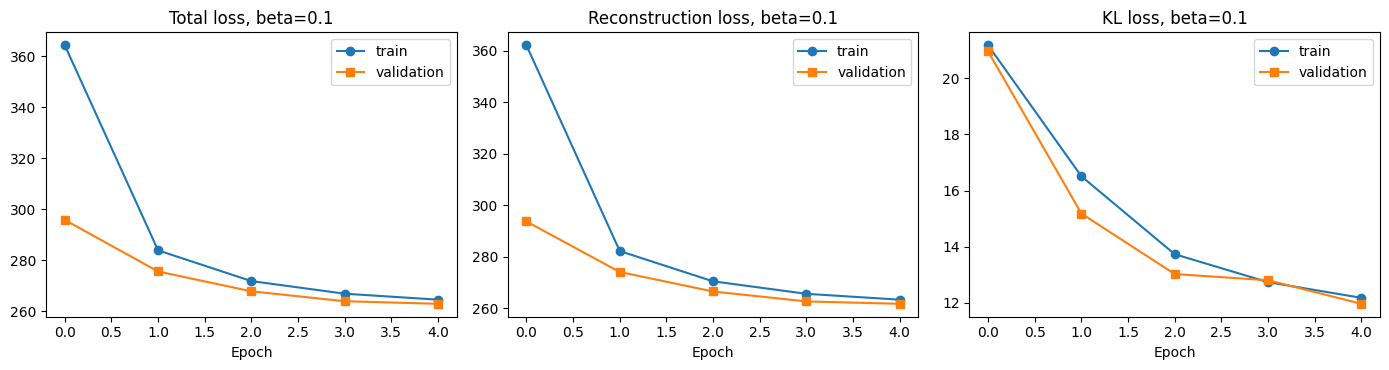

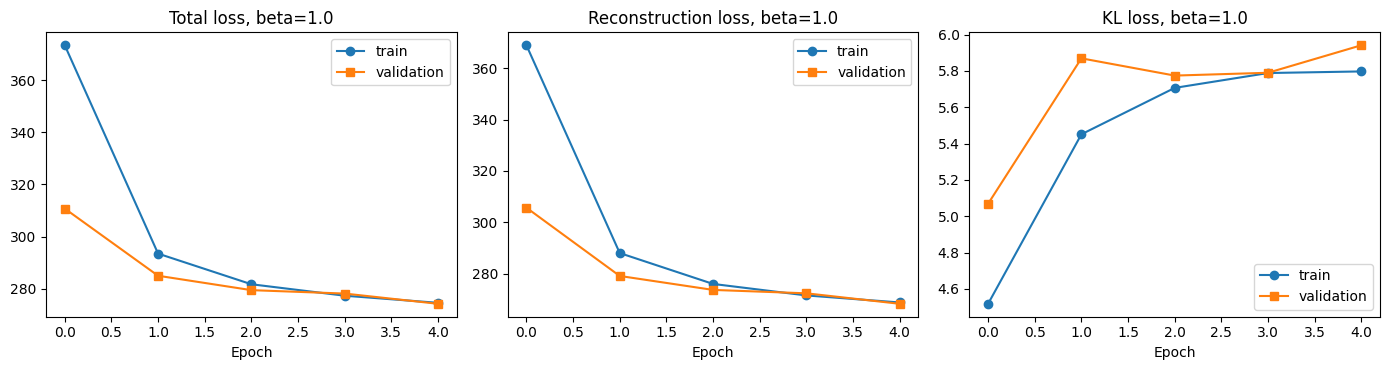

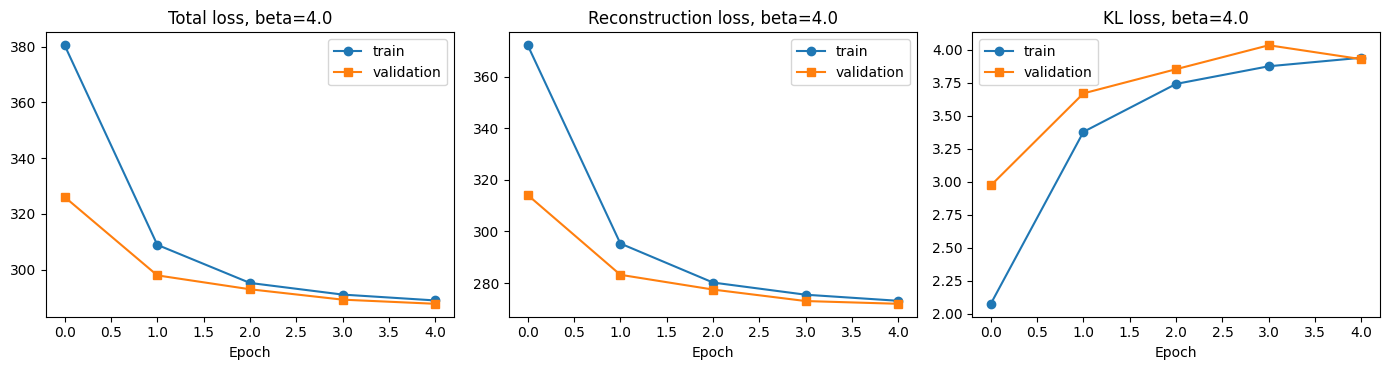

In [17]:
for beta, record in experiment_results.items():
    fig = plot_training_curves(
        record["history"].history,
        beta,
        save_path=FIGURE_DIR / f"training_curves_beta_{beta}.png",
    )
    plt.show()


## 12. Reconstruction Quality Comparison

We reconstruct the same test images for every beta. Using the same examples makes the visual comparison fair. In many beta-VAE runs, lower beta values keep more image detail, while higher beta values trade detail for stronger latent regularization.


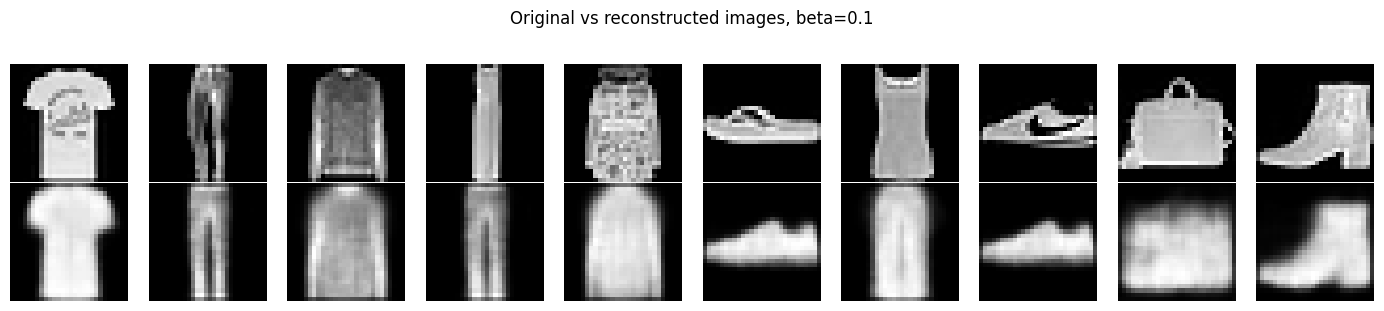

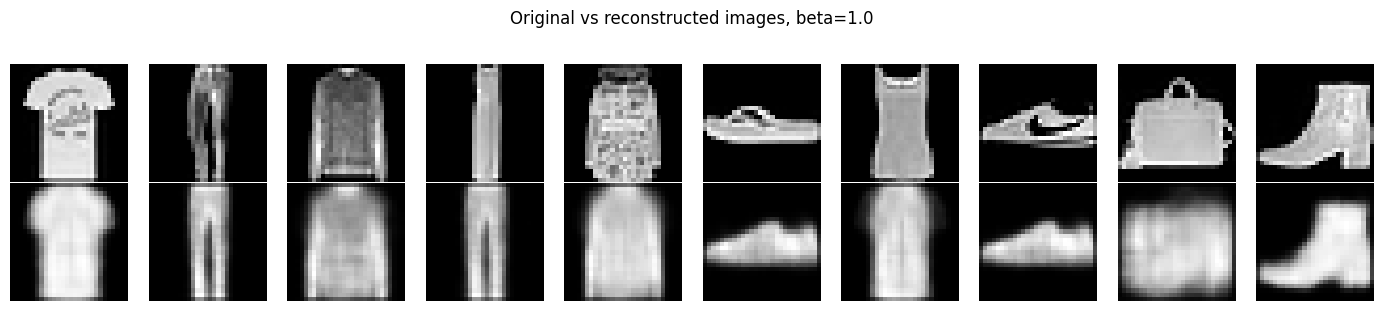

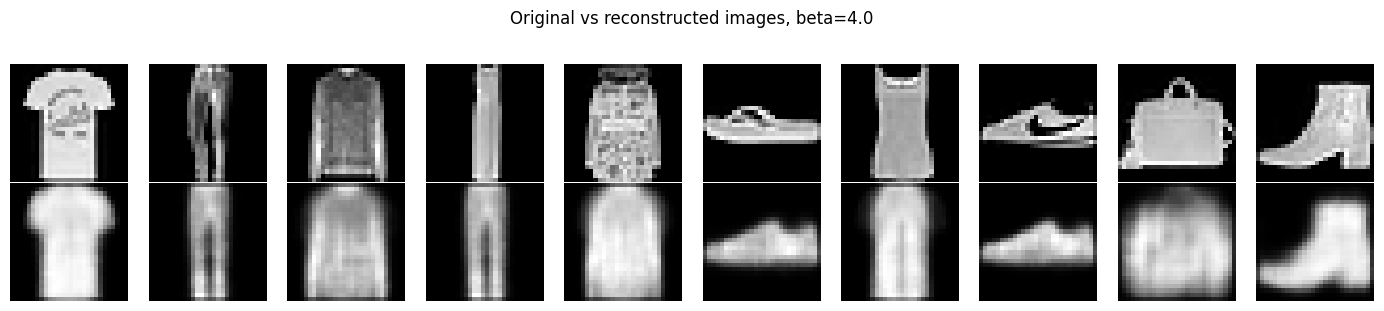

In [18]:
selected_reconstruction_indices = []
for class_id in range(len(class_names)):
    matches = np.where(y_test_vis == class_id)[0]
    if len(matches) > 0:
        selected_reconstruction_indices.append(matches[0])
    if len(selected_reconstruction_indices) == 10:
        break
if len(selected_reconstruction_indices) < 10:
    selected_reconstruction_indices = list(range(10))

reconstruction_examples = x_test_vis[selected_reconstruction_indices[:10]]

for beta, record in experiment_results.items():
    reconstructions = reconstruct_with_mean(record["encoder"], record["decoder"], reconstruction_examples)
    plot_reconstruction_grid(
        reconstruction_examples,
        reconstructions,
        title=f"Original vs reconstructed images, beta={beta}",
        n=10,
        save_path=FIGURE_DIR / f"reconstructions_beta_{beta}.png",
    )
    plt.show()


Interpretation guide:

- `beta = 0.1` usually prioritizes reconstruction and may preserve sharper details, but the latent distribution may be less regular.
- `beta = 1.0` is the standard VAE balance between reconstruction and prior regularization.
- `beta = 4.0` pushes harder toward the normal prior and can organize the latent space more strongly, but reconstructed images may become blurrier.

The actual conclusion should be based on the plots and loss table from this run, not only on the usual expectation.


## 13. 2D Latent Space Visualization

Because `latent_dim = 2`, we can directly plot the two coordinates of `z_mean`. Labels are used only for color. This plot can suggest latent organization, but it is not a rigorous proof of disentanglement.


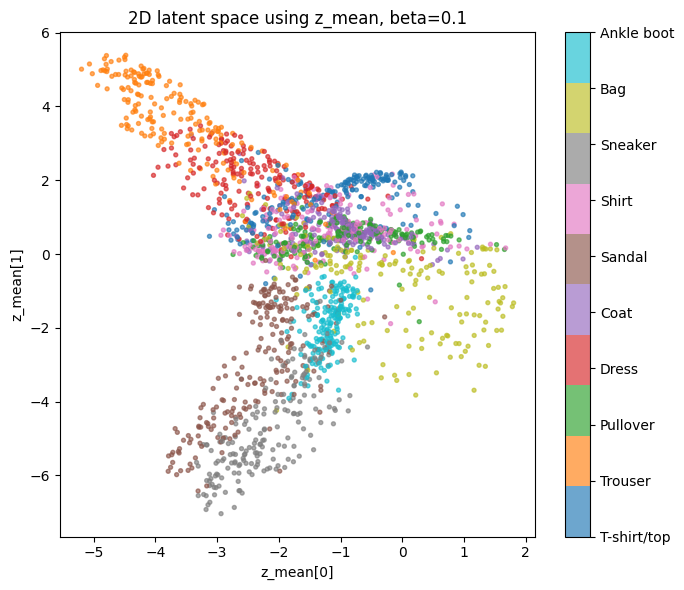

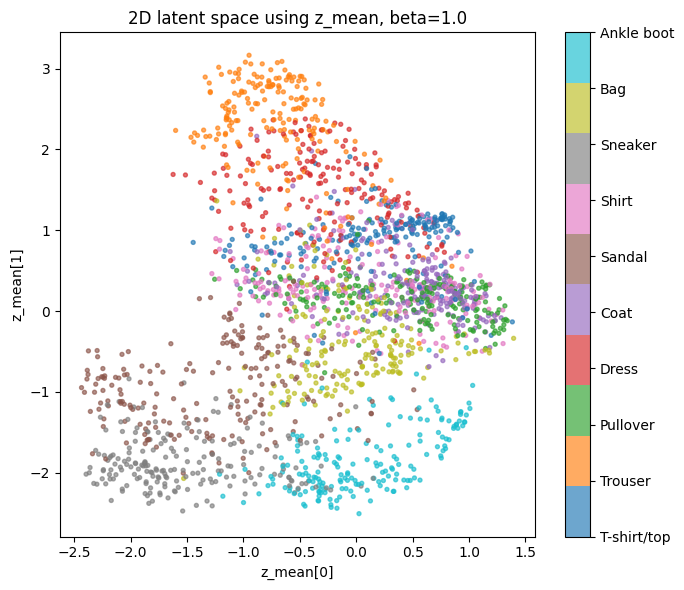

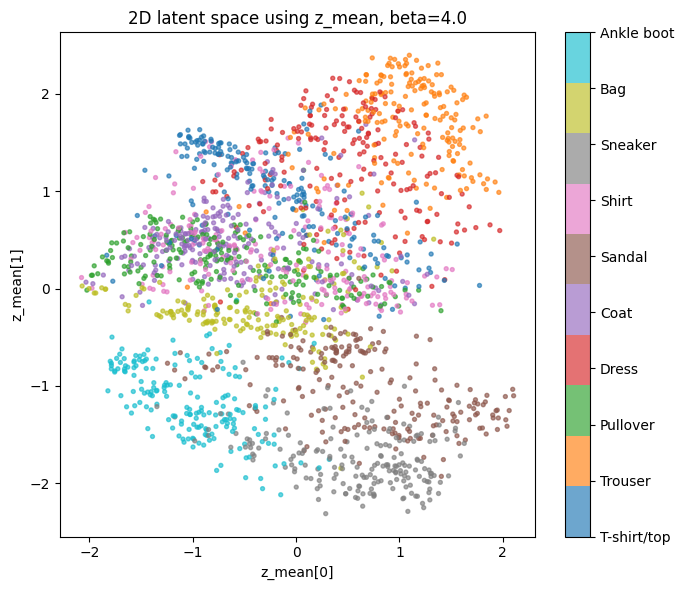

In [19]:
for beta, record in experiment_results.items():
    plot_latent_space(
        record["encoder"],
        x_test_vis,
        y_test_vis,
        class_names,
        title=f"2D latent space using z_mean, beta={beta}",
        n_samples=TEST_VIS_SIZE,
        save_path=FIGURE_DIR / f"latent_space_beta_{beta}.png",
    )
    plt.show()


If points from similar classes form nearby regions, the latent representation has learned useful structure. However, true disentanglement is hard to prove visually and would require more formal metrics and controlled factors of variation.


## 14. Random Latent Sampling

A VAE can generate new images by sampling latent vectors from a standard normal distribution and decoding them. Better regularized latent spaces usually decode random samples more reliably.


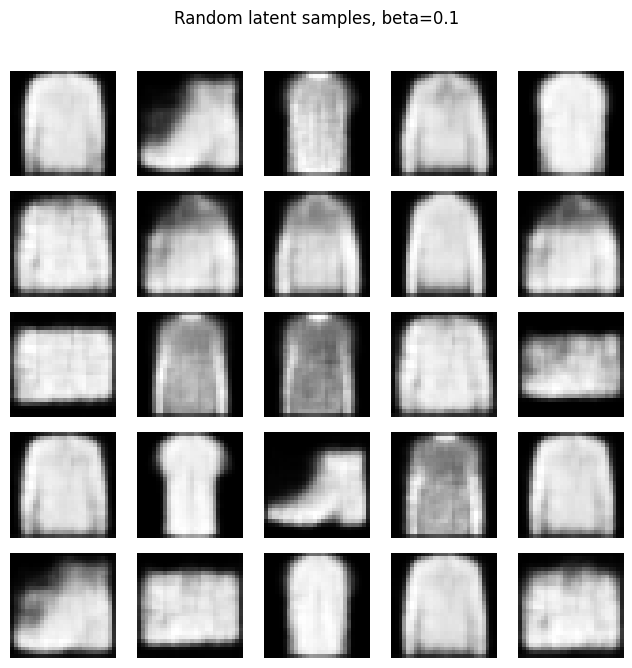

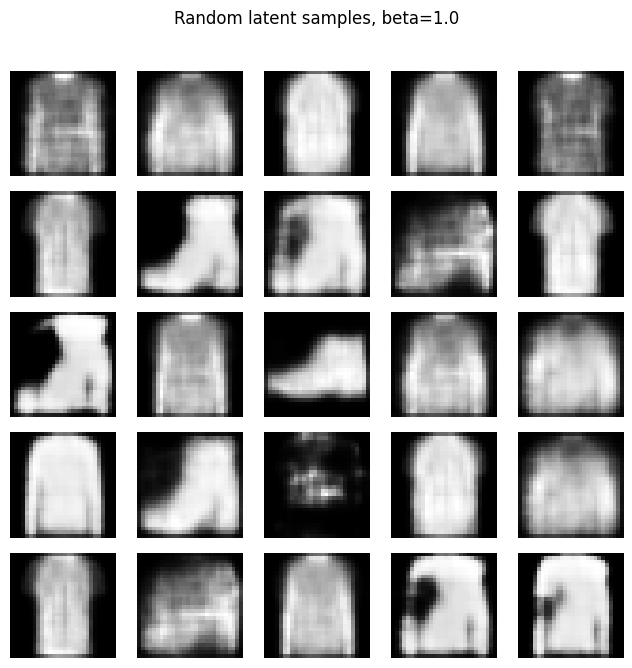

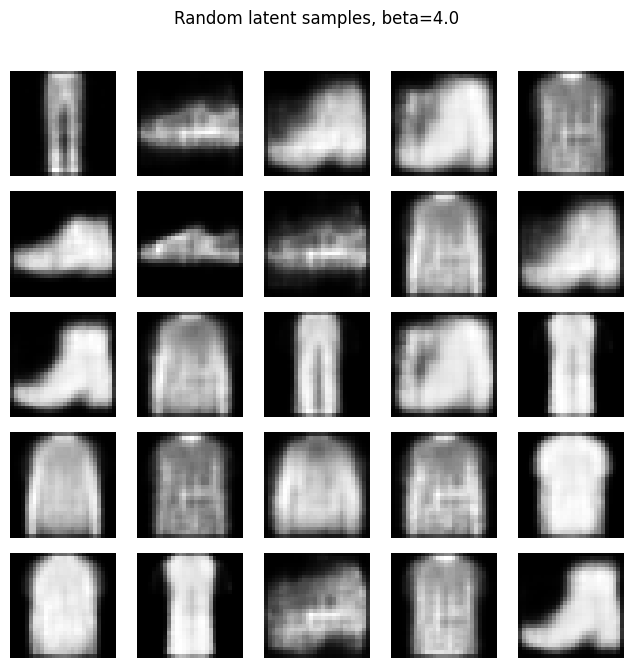

In [20]:
for beta, record in experiment_results.items():
    generated = sample_random_latent_and_generate(
        record["decoder"],
        LATENT_DIM,
        n=25,
        seed=RANDOM_SEED + int(beta * 10),
    )
    plot_generated_grid(
        generated,
        title=f"Random latent samples, beta={beta}",
        n=25,
        save_path=FIGURE_DIR / f"generated_samples_beta_{beta}.png",
    )
    plt.show()


The generated grids show whether random points from the prior decode into plausible images. Diversity and recognizable structure both matter, but with only a few epochs we should expect imperfect samples.


## 15. Latent Space Interpolation

Interpolation tests whether the decoder changes images smoothly between two encoded test examples. A smooth transition suggests that the latent space has learned a meaningful continuous representation.


Start class: T-shirt/top
End class: Trouser


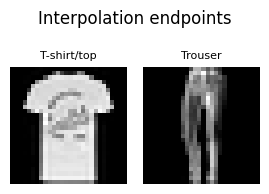

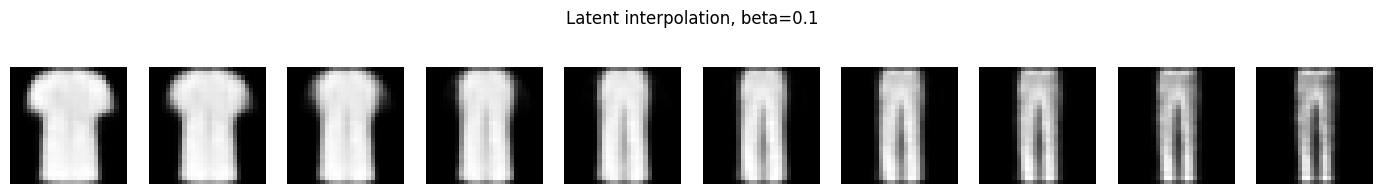

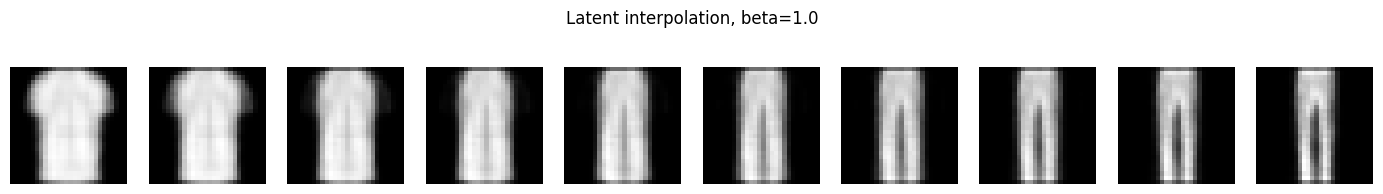

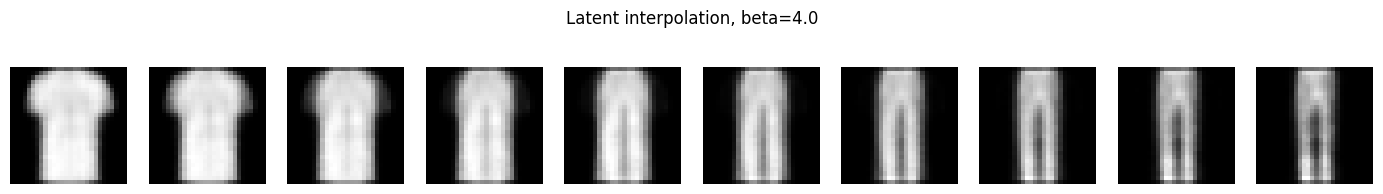

In [21]:
def find_interpolation_pair(labels):
    first_label = int(labels[0])
    for idx, label in enumerate(labels):
        if int(label) != first_label:
            return 0, idx
    return 0, min(1, len(labels) - 1)


start_idx, end_idx = find_interpolation_pair(y_test_vis)
start_image = x_test_vis[start_idx:start_idx + 1]
end_image = x_test_vis[end_idx:end_idx + 1]

print("Start class:", class_names[int(y_test_vis[start_idx])])
print("End class:", class_names[int(y_test_vis[end_idx])])

plot_image_grid(
    np.concatenate([start_image, end_image], axis=0),
    "Interpolation endpoints",
    n=2,
    labels=[y_test_vis[start_idx], y_test_vis[end_idx]],
    class_names=class_names,
    save_path=FIGURE_DIR / "interpolation_endpoints.png",
)
plt.show()

for beta, record in experiment_results.items():
    z_start, _, _ = record["encoder"].predict(start_image, verbose=0)
    z_end, _, _ = record["encoder"].predict(end_image, verbose=0)
    interpolate_and_plot(
        record["decoder"],
        z_start[0],
        z_end[0],
        steps=10,
        title=f"Latent interpolation, beta={beta}",
        save_path=FIGURE_DIR / f"interpolation_beta_{beta}.png",
    )
    plt.show()


The best interpolation is not necessarily the sharpest one. We look for gradual changes where neighboring latent points decode into neighboring visual concepts.


## 16. Optional 2D Latent Grid

With a 2D latent space, we can decode a regular grid of latent coordinates. This gives a map-like view of what the decoder has learned across the prior space.


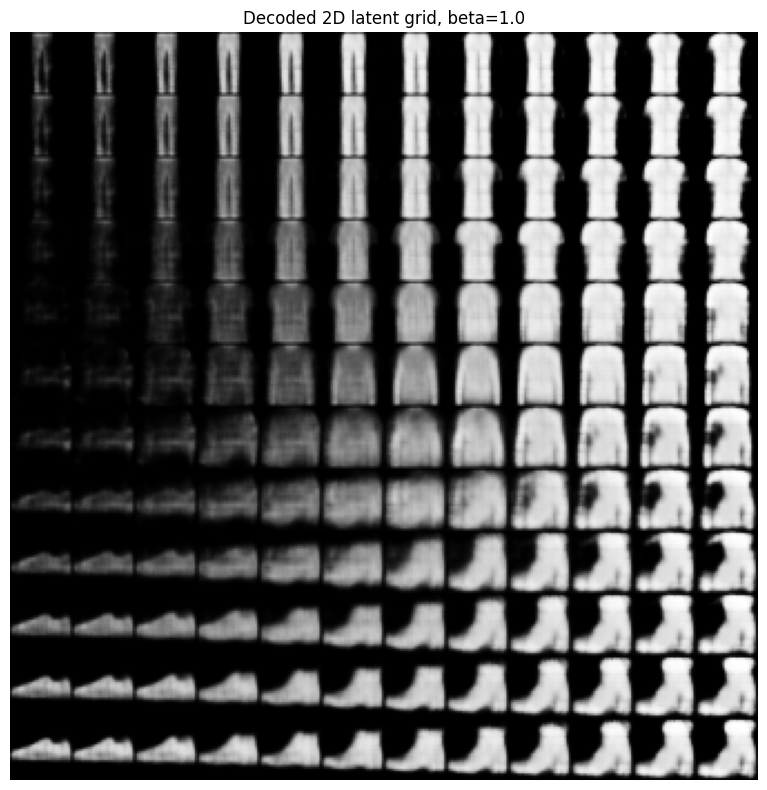

In [22]:
def plot_latent_grid(decoder, beta, grid_size=12, extent=2.5, save_path=None):
    grid_x = np.linspace(-extent, extent, grid_size)
    grid_y = np.linspace(extent, -extent, grid_size)
    z_points = np.array([[x, y] for y in grid_y for x in grid_x], dtype="float32")
    decoded = decoder.predict(z_points, verbose=0)

    canvas = np.zeros((grid_size * IMG_HEIGHT, grid_size * IMG_WIDTH), dtype="float32")
    for idx, image in enumerate(decoded):
        row = idx // grid_size
        col = idx % grid_size
        canvas[
            row * IMG_HEIGHT:(row + 1) * IMG_HEIGHT,
            col * IMG_WIDTH:(col + 1) * IMG_WIDTH,
        ] = image.squeeze()

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(canvas, cmap="gray")
    ax.axis("off")
    ax.set_title(f"Decoded 2D latent grid, beta={beta}")
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig


grid_beta = 1.0 if 1.0 in experiment_results else BETAS[0]
plot_latent_grid(
    experiment_results[grid_beta]["decoder"],
    beta=grid_beta,
    save_path=FIGURE_DIR / f"latent_grid_beta_{grid_beta}.png",
)
plt.show()


## 17. Final Analysis

The next cell summarizes this specific run using the saved metrics. The visual plots should be used together with these numbers: reconstruction loss captures pixel-level accuracy, while KL loss reflects latent regularization pressure.


In [23]:
best_reconstruction_row = results_df.loc[results_df["final_val_reconstruction_loss"].idxmin()]
best_total_row = results_df.loc[results_df["final_val_total_loss"].idxmin()]
lowest_kl_row = results_df.loc[results_df["final_val_kl_loss"].idxmin()]
strongest_beta = max(BETAS)

analysis_text = f"""
### Final analysis based on this run

- The lowest validation reconstruction loss was obtained with beta = {best_reconstruction_row['beta']}.
- The lowest validation total loss was obtained with beta = {best_total_row['beta']}.
- The smallest validation KL loss was obtained with beta = {lowest_kl_row['beta']}, while beta = {strongest_beta} applies the strongest explicit KL pressure.
- Lower beta values usually give the decoder more freedom to preserve image detail. If their reconstructions look sharper here, that matches the reconstruction-first objective.
- Higher beta values usually force latent codes closer to the standard normal prior. If random samples or latent scatter plots look more organized for higher beta, that matches the regularization-first objective.
- The latent scatter plots can suggest class organization, but they do not prove true disentanglement. A stronger claim would need quantitative metrics and known generative factors.
- This is a deliberately small CPU-friendly experiment. More epochs, a larger latent dimension, a deeper architecture, and more training data would likely improve image quality and sample diversity.
"""

display(Markdown(analysis_text))



### Final analysis based on this run

- The lowest validation reconstruction loss was obtained with beta = 0.1.
- The lowest validation total loss was obtained with beta = 0.1.
- The smallest validation KL loss was obtained with beta = 4.0, while beta = 4.0 applies the strongest explicit KL pressure.
- Lower beta values usually give the decoder more freedom to preserve image detail. If their reconstructions look sharper here, that matches the reconstruction-first objective.
- Higher beta values usually force latent codes closer to the standard normal prior. If random samples or latent scatter plots look more organized for higher beta, that matches the regularization-first objective.
- The latent scatter plots can suggest class organization, but they do not prove true disentanglement. A stronger claim would need quantitative metrics and known generative factors.
- This is a deliberately small CPU-friendly experiment. More epochs, a larger latent dimension, a deeper architecture, and more training data would likely improve image quality and sample diversity.
